# Calibration runs with the validation dataset

Using the test and run segmentation utility (which is somewhat barebones but indicates some quality) I can do a side-by-side comparison of the FSPipeline and the LA2019 pipelines for the 100km by 100km cases. To start with, I set it up to do a semi-random subset of the cases by selecting those with less than 50% clouds, visible floes, and case numbers evenly divisible by 3. That's about 26 cases. I'm 

In [141]:
import skimage.io as io
import skimage
import numpy as np
import pandas as pd
import ultraplot as uplt
import os

%run ../scripts/segmentation_evaluation_functions.py

In [217]:
results_loc = "/Users/dwatkin2/Documents/research/packages/IceFloeTracker.jl/test/test_outputs/"
# os.listdir(results_loc)

In [218]:
la2019_df = pd.read_csv(results_loc + "LopezAcosta2019_sampled.csv")
fspipeline_df = pd.read_csv(results_loc + "FSPipeline_sampled.csv")

In [219]:
fsp_files = [f for f in os.listdir(results_loc) if 'FSPipeline.Segment' in f]
la2019_files = [f for f in os.listdir(results_loc) if 'LopezAcosta2019.Segment' in f]
fsp_files.sort()
la2019_files.sort()

In [220]:
fsp_files

['segmentation-IceFloeTracker.FSPipeline.Segment-006-baffin_bay-100km-20220530-aqua-250m-2026-03-12-140313',
 'segmentation-IceFloeTracker.FSPipeline.Segment-006-baffin_bay-100km-20220530-terra-250m-2026-03-12-140258',
 'segmentation-IceFloeTracker.FSPipeline.Segment-012-baffin_bay-100km-20090426-aqua-250m-2026-03-12-140317',
 'segmentation-IceFloeTracker.FSPipeline.Segment-012-baffin_bay-100km-20090426-terra-250m-2026-03-12-140315',
 'segmentation-IceFloeTracker.FSPipeline.Segment-014-baffin_bay-100km-20220706-aqua-250m-2026-03-12-140318',
 'segmentation-IceFloeTracker.FSPipeline.Segment-014-baffin_bay-100km-20220706-terra-250m-2026-03-12-140320',
 'segmentation-IceFloeTracker.FSPipeline.Segment-018-baffin_bay-100km-20120915-aqua-250m-2026-03-12-140321',
 'segmentation-IceFloeTracker.FSPipeline.Segment-018-baffin_bay-100km-20120915-terra-250m-2026-03-12-140322',
 'segmentation-IceFloeTracker.FSPipeline.Segment-032-barents_kara_seas-100km-20140501-aqua-250m-2026-03-12-140324',
 'segmen

In [221]:
la2019_df.case_name = [" ".join(case.split("-")[0:2]) for case in la2019_df.case_name]
fspipeline_df.case_name = [" ".join(case.split("-")[0:2]) for case in fspipeline_df.case_name]

In [222]:
fspipeline_df

,case_name,success,recall,precision,F_score,labeled_fraction,segment_count
0,006 baffin_bay,True,0.290447,0.766431,0.421255,0.109738,75
1,006 baffin_bay,True,0.322087,0.728417,0.446669,0.127125,76
2,012 baffin_bay,True,0.664112,0.231570,0.343399,0.264256,23
3,012 baffin_bay,True,0.787386,0.231791,0.358150,0.292181,17
4,014 baffin_bay,True,0.400030,0.608599,0.482750,0.081406,41
5,014 baffin_bay,True,0.378615,0.658758,0.480860,0.076394,40
6,018 baffin_bay,True,0.251901,0.201694,0.224019,0.023613,15
7,018 baffin_bay,True,0.151035,0.105506,0.124230,0.020319,12
8,032 barents_kara_seas,True,0.135877,0.055884,0.079196,0.045406,39
9,032 barents_kara_seas,True,0.206312,0.075996,0.111076,0.058063,37


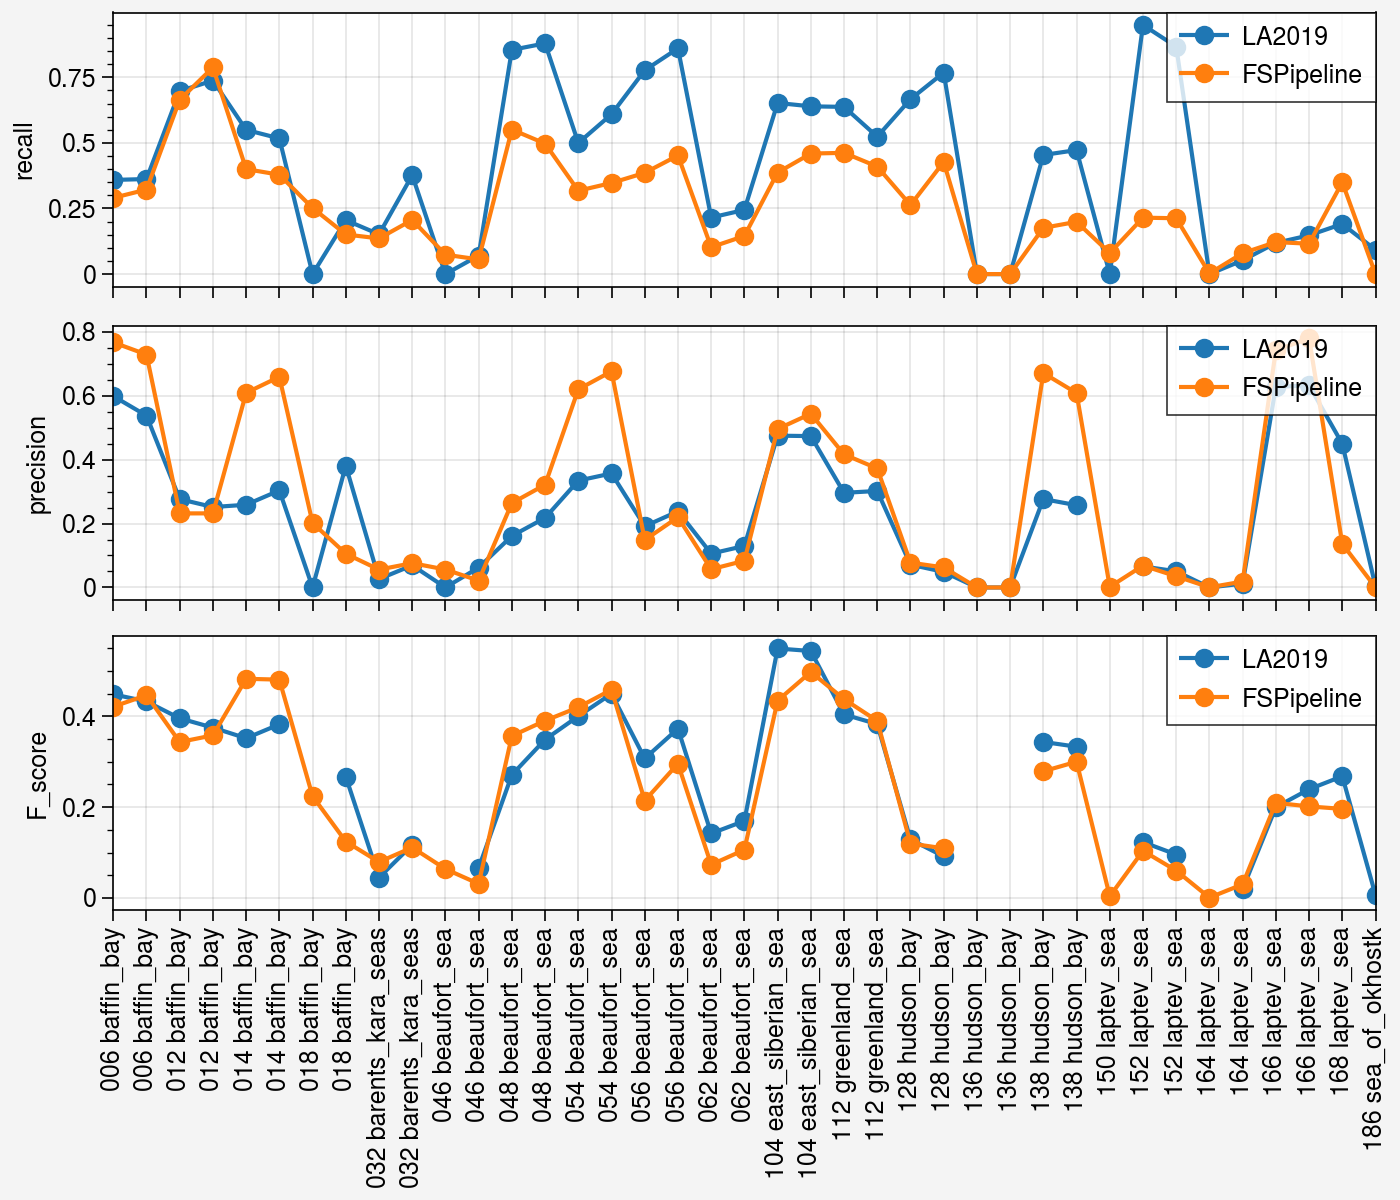

In [223]:
fig, axs = uplt.subplots(width=7, height=6, nrows=3, sharey=False)
for ax, meas in zip(axs, ["recall", "precision", "F_score"]):
    ax.plot(la2019_df[meas], marker='o', color='tab:blue', label='LA2019')
    ax.plot(fspipeline_df[meas], marker='o', color='tab:orange', label='FSPipeline')
    ax.format(xformatter=[x for x in fspipeline_df.case_name], xlocator=fspipeline_df.index, xrotation=90)
    ax.legend(loc='ur', ncols=1)

In [225]:
merged_df = fspipeline_df.merge(la2019_df, left_on='case_name', right_on='case_name')

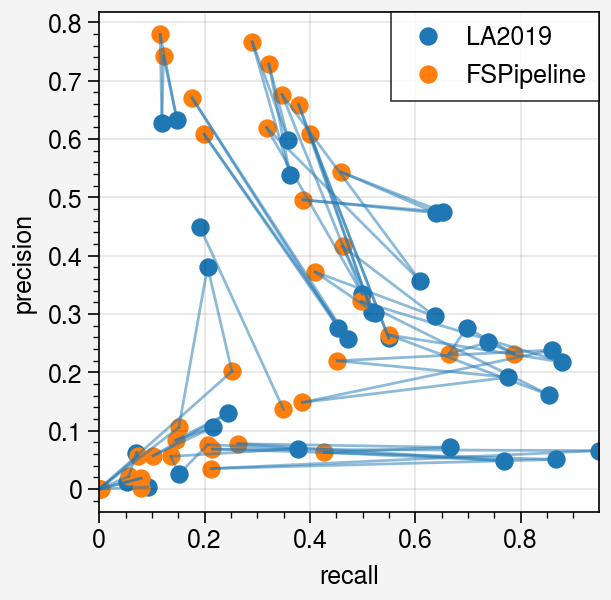

In [226]:
fig, ax = uplt.subplots()
for row_id, data in merged_df.iterrows():
    ax.plot([data.recall_y, data.recall_x], [data.precision_y, data.precision_x],
            color='tab:blue', alpha=0.5, lw=1)
    
ax.scatter(la2019_df['recall'],
        la2019_df['precision'], marker='o', color='tab:blue', label='LA2019')
ax.scatter(fspipeline_df['recall'],
        fspipeline_df['precision'], marker='o', color='tab:orange', label='FSPipeline')
ax.legend(loc='ur', ncols=1)
ax.format(xreverse=False, yreverse=False)

# Compute and plot comparisons

In [246]:
# Images to load: FSPipeline | LA2019
# truecolor.png
# final_floes.png | segF.png
# segA.png
# sharpened_grayscale_image.png
# coastal_buffer.png

object_wise_measures = {}
area_and_centroids = {}
for idx in range(len(fsp_files)):
    os.listdir(results_loc + fsp_files[idx])
    case_number = fsp_files[idx].split('-')[2]
    region = fsp_files[idx].split('-')[3]
    satellite = fsp_files[idx].split('-')[6]
    
    results_images = {
        "truecolor": io.imread(os.path.join(results_loc, fsp_files[idx], "truecolor.png")),
        "falsecolor": io.imread(os.path.join(results_loc, fsp_files[idx], "falsecolor.png")),
        "validated":  io.imread(os.path.join(results_loc, fsp_files[idx], "validated_binary.png")),
        "kmeans_init":  {'LA2019': io.imread(os.path.join(results_loc, la2019_files[idx], "segAB_intersect.png")),
                        'FSP':  io.imread(os.path.join(results_loc, fsp_files[idx], "segAB_intersect.png"))}, 
        "final_floes": {'LA2019': io.imread(os.path.join(results_loc, la2019_files[idx], "final_floes.png")),
                        'FSP':  io.imread(os.path.join(results_loc, fsp_files[idx], "final_floes.png"))},
        "preprocessed": {'LA2019': io.imread(os.path.join(results_loc, la2019_files[idx], "sharpened_grayscale_image.png")),
                        'FSP':  io.imread(os.path.join(results_loc, fsp_files[idx], "sharpened_grayscale_image.png"))},
        "coast_mask": {'LA2019': io.imread(os.path.join(results_loc, la2019_files[idx], "coastal_buffer.png")),
                        'FSP':  io.imread(os.path.join(results_loc, fsp_files[idx], "coastal_buffer.png"))},
    }

    centroid_comparison = {}
    for method in ["LA2019", "FSP"]:
        gt_img = sk.measure.label(results_images["validated"])
        seg_image = sk.measure.label(results_images["final_floes"][method])
        gt_img_props = {floe.label: floe for floe in sk.measure.regionprops(gt_image)}
        seg_img_props = {floe.label: floe for floe in sk.measure.regionprops(seg_image)}
        min_area = 300
        temp_results = []
        for label_i in gt_img_props:
            if gt_img_props[label_i].area >= min_area:
                ref_set = select_relevant_set(label_i=label_i, gt_image=gt_image, seg_image=seg_image,
                                gt_image_props=gt_img_props, seg_image_props=seg_img_props, thresh=0.5)
                yc, xc = gt_img_props[label_i].centroid 
                a = gt_img_props[label_i].area
                
                if len(ref_set) == 0:
                    temp_results.append([label_i, xc, yc, a, np.nan, np.nan, np.nan])
                else:
                    for label_j in ref_set:
                        seg_yc, seg_xc = seg_img_props[label_j].centroid 
                        seg_a = seg_img_props[label_j].area
                        temp_results.append([label_i, xc, yc, a, seg_xc, seg_yc, seg_a])

        centroid_comparison[method] = pd.DataFrame(temp_results, columns=["Label", "ColTrue", "RowTrue", "AreaTrue", "ColPred", "RowPred", "AreaPred"])
    area_and_centroids[case_number + "_" + satellite] = centroid_comparison
    
    # TBD: Add Seg AB result
    fig, ax = uplt.subplots(nrows=2, ncols=5, share=False)
    ax[0, 0].imshow(results_images["truecolor"])
    ax[1, 0].imshow(results_images["falsecolor"])
    ax[0,0].format(title="True Color")
    ax[1, 0].format(title="False Color")
    fig.format(suptitle="Case " + case_number)
    
    
    for row, name in zip([0, 1], ["LA2019", "FSP"]):
        ax[row, 1].imshow(results_images["preprocessed"][name], cmap='mono_r')
        ax[row, 2].imshow(np.ma.masked_array(results_images["kmeans_init"][name], results_images["kmeans_init"][name]==0), c='blue8', alpha=0.75)
        ax[row, 2].imshow(np.ma.masked_array(results_images["final_floes"][name], results_images["final_floes"][name]==0), c='red6', alpha=0.75)
        ax[row, 3].imshow(np.ma.masked_array(results_images["validated"], results_images["validated"]==0), c='k', alpha=0.5)
        ax[row, 3].imshow(np.ma.masked_array(results_images["final_floes"][name], results_images["final_floes"][name]==0), c='red6', alpha=0.75)
    
        ax[row, 1].format(title=name + " Preprocessed")
        ax[row, 2].format(title=name + " Segmentation")
        ax[row, 3].format(title=name + " Validated")
    
        h = [ax.plot([], [], color='blue8', m='s', lw=0, alpha=0.75), 
             ax.plot([], [], color='red6', m='s', lw=0, alpha=0.75)]
        ax[row, 2].legend(h, ["Seg. A", "Final"], ncols=1, loc='ll', alpha=1)
        h = [ax.plot([], [], color='k', m='s', lw=0, alpha=0.5), 
             ax.plot([], [], color='red6', m='s', lw=0, alpha=0.75)]
        ax[row, 3].legend(h, ["Validated", "Final"], ncols=1, loc='ll', alpha=1)    
    
        ax[row, 4].scatter(centroid_comparison[name]["RowTrue"], centroid_comparison[name]["RowPred"], marker='d', color='slateblue', label="Row")
        ax[row, 4].scatter(centroid_comparison[name]["ColTrue"], centroid_comparison[name]["ColPred"], marker='s', color='tab:green', label="Col")
        ax[row, 4].format(xreverse = False, ylabel="Segmented", xlabel="Validated", title=name + ' Centroids')
        ax[row, 4].legend(loc='ul', alpha=1, ncols=1)

    fig.save("../figures/comparison_fsp_la2019/case_" + str(case_number) + "_comparison_fsp_la2019.png", dpi=300)
    uplt.close(fig)
   
    test_results = {}
    try: 
        gt_image = skimage.measure.label(results_images['validated'])
        seg_image = skimage.measure.label(results_images['final_floes']['LA2019'])
        test_results['LA2019'] = compute_metrics(gt_image, seg_image, return_type='weighted')
    except:
        print("Object-wise measures failed for ", case_number, region, satellite, "LA2019")  
    try:
        seg_image = skimage.measure.label(results_images['final_floes']['FSP'])
        test_results['FSP'] = compute_metrics(gt_image, seg_image, return_type='weighted')
        object_wise_measures[idx] = pd.DataFrame(test_results)
    except:
        print("Object-wise measures failed for ", case_number, region, satellite, "FSP")  


Object-wise measures failed for  006 baffin_bay aqua FSP
Object-wise measures failed for  012 baffin_bay terra FSP
Object-wise measures failed for  018 baffin_bay aqua LA2019
Object-wise measures failed for  046 beaufort_sea aqua LA2019
Object-wise measures failed for  046 beaufort_sea terra LA2019
Object-wise measures failed for  046 beaufort_sea terra FSP
Object-wise measures failed for  136 hudson_bay aqua LA2019
Object-wise measures failed for  136 hudson_bay aqua FSP
Object-wise measures failed for  136 hudson_bay terra LA2019
Object-wise measures failed for  136 hudson_bay terra FSP
Object-wise measures failed for  138 hudson_bay aqua LA2019
Object-wise measures failed for  138 hudson_bay aqua FSP
Object-wise measures failed for  150 laptev_sea aqua LA2019
Object-wise measures failed for  152 laptev_sea terra LA2019
Object-wise measures failed for  164 laptev_sea aqua LA2019
Object-wise measures failed for  164 laptev_sea aqua FSP
Object-wise measures failed for  186 sea_of_okhos

In [245]:
area_and_centroids['006_aqua']

{'LA2019': Empty DataFrame
 Columns: [Label, ColTrue, RowTrue, AreaTrue, ColPred, RowPred, AreaPred]
 Index: [],
 'FSP': Empty DataFrame
 Columns: [Label, ColTrue, RowTrue, AreaTrue, ColPred, RowPred, AreaPred]
 Index: []}

# Questions and notes
The initial measures give us a hint of the performance differences but should not be over-interpreted. I'll need to use some care when it comes to edge cases, for example. It does seem to me that there is enough information here to do some initial calibration for the IFT cal-val paper, which could then be more extensively validated


- Can we consider the final segmentation result to be markers, and use the intermediate Segmentation A or watershed boundaries result to retrieve the correct edge? Active contour model using the original marker as the starting point, e.g.
- Does the final segmentation step

In [171]:
la2019_objectwise = pd.DataFrame({idx: object_wise_measures[idx]['LA2019'] for idx in object_wise_measures if 'LA2019' in object_wise_measures[idx]})
fsp_objectwise = pd.DataFrame({idx: object_wise_measures[idx]['FSP'] for idx in object_wise_measures})

In [173]:
measures = la2019_objectwise.index
measures

Index(['label_i', 'area_i', 'area_j', 'overlap', 'area_relative_error',
       'area_similarity_ratio', 'normalized_area_diff_ratio',
       'undersegmentation_error', 'oversegmentation_error',
       'segmentation_error', 'euclidean_distance', 'hausdorff_distance',
       'modified_hausdorff_distance', 'shape_dissimilarity',
       'directed_boundary_f_score', 'dilated_boundary_f_score', 'n'],
      dtype='object')

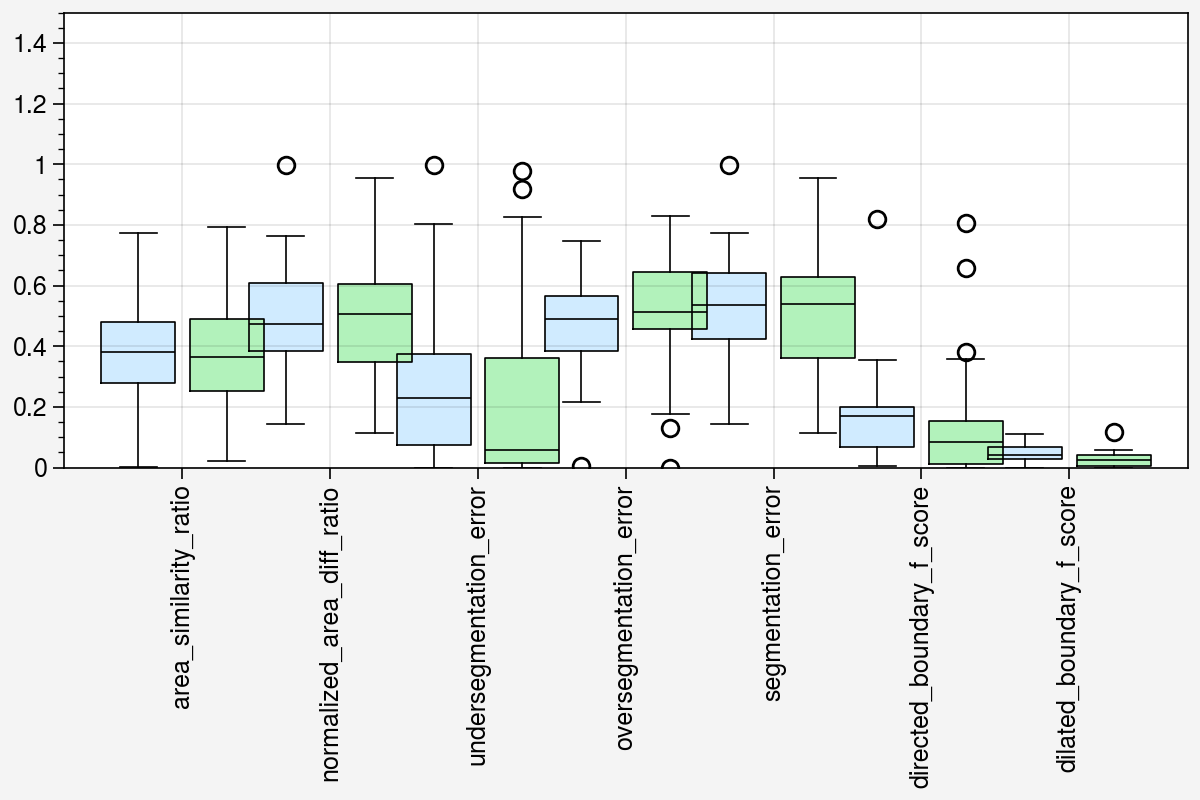

In [198]:
comp_set = ['area_similarity_ratio', 'normalized_area_diff_ratio',
            'undersegmentation_error', 'oversegmentation_error',
            'segmentation_error', 
            'directed_boundary_f_score', 'dilated_boundary_f_score']
n = len(comp_set)
fig, ax = uplt.subplots(width=6, height=4)
ax.box(np.arange(n) - 0.3, la2019_objectwise.loc[comp_set, :].T,
       facecolor='blue1')
ax.box(np.arange(n) + 0.3, fsp_objectwise.loc[comp_set, :].T, facecolor='green2')
ax.format(ylim=(0, 1.5), xtickminor=False, xrotation=90, xlocator=range(n), xformatter=comp_set)

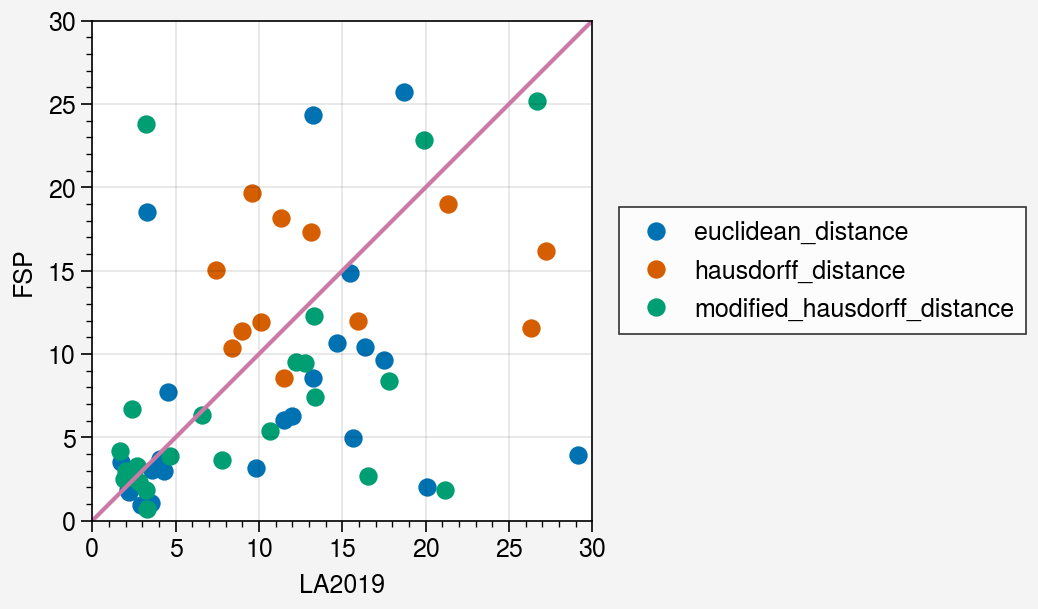

In [207]:
comp_set = ['euclidean_distance', 'hausdorff_distance', 'modified_hausdorff_distance']
fig, ax = uplt.subplots()
cols = [idx for idx in la2019_objectwise.columns if idx in fsp_objectwise.columns]
for meas in comp_set:
    ax.scatter(la2019_objectwise.loc[meas, cols], fsp_objectwise.loc[meas, cols], label=meas)
ax.plot([0, 30], [0, 30])
ax.format(ylim=(0, 30), xlim=(0, 30), xlabel='LA2019', ylabel='FSP')
ax.legend(ncols=1, loc='r')

In [38]:
dataloc = "../../../greenland_floe_scale_dataset/IFT_greenland_sea_dataset/data/FSPipeline_results/binary_lacm_clip02/"

fs_pipeline_results = os.listdir(dataloc)
fs_pipeline_results = [f for f in fs_pipeline_results if 'png' in f]
fs_pipeline_results.sort()

In [6]:
os.listdir(dataloc)

['.DS_Store', 'binary_lacm_clip02']

In [8]:
binary_imgs = [io.imread(dataloc + f) for f in fs_pipeline_results]

In [15]:
dataloc_share = "/Volumes/Research/ENG_Wilhelmus_Shared/group/IFT_greenland_sea_floe_trajectories/greenland_sea_ift_dataset/"

In [17]:
# cloud masks - on share drive
cloudmasks = []
prelim_icemasks = []
for f in fs_pipeline_results:
    year = f[0:4]
    cloudmasks.append(io.imread(dataloc_share + 'cloudmask' + '/' + year + '/' + f.replace('binary_floes', 'cloudmask')))
    prelim_icemasks.append(io.imread(dataloc_share  + 'prelim_icemask' + '/' + year + '/' +  f.replace('binary_floes', 'prelim_icemask')))
# ASI ice masks - on share drive

In [31]:
landmask = io.imread(dataloc_share + 'landmask.tiff')[:, :, 0]

In [47]:
fs_pipeline_results[0]

'200304011210.aqua.binary_floes.png'

In [54]:
# Example overlay
for idx in range(len(fs_pipeline_results)):
    date = fs_pipeline_results[idx].split('.')[0]
    date = pd.to_datetime(date)
    satellite = fs_pipeline_results[idx].split('.')[1]
    
    fig, ax = uplt.subplots()
    # land and water
    ax.imshow(np.ma.masked_array(landmask, landmask==0), color='k')
    water = (landmask == 0) & (cloudmasks[idx] == 0)
    ax.imshow(np.ma.masked_array(water, mask = water == 0), color='blue5')
    
    # preliminary ice mask
    ax.imshow(np.ma.masked_array(prelim_icemasks[idx], prelim_icemasks[idx]==0), color='light gray')
    
    # IFT initial results
    ax.imshow(np.ma.masked_array(binary_imgs[idx], binary_imgs[idx]==0), color='w')
    
    # Stricter cloud mask
    ax.imshow(np.ma.masked_array(cloudmasks[idx], cloudmasks[idx]==0), color='lilac', alpha=0.75)
    
    
    h = [ax.plot([],[],marker='s', lw=0, color=c) for c in ['k', 'blue5', 'light gray', 'w', 'lilac']]
    ax.legend(h, ['Land', 'Water', 'Ice', 'Bright Ice', 'Clouds'], ncols=1, loc='ll', alpha=1)
    ax.format(ltitle=satellite.title(), rtitle=date.strftime('%Y-%m-%d'), xticks='none', yticks='none')
    fig.save('../figures/animations/fspipeline_april_2003_classified/frame_{i}.png'.format(i=str(idx).zfill(3)), dpi=300)
    uplt.close(fig)

In [43]:
masked_ice_images = np.array(
        [np.ma.masked_array(binary_imgs[idx], mask=cloudmasks[idx]) for idx in range(len(cloudmasks))]
)

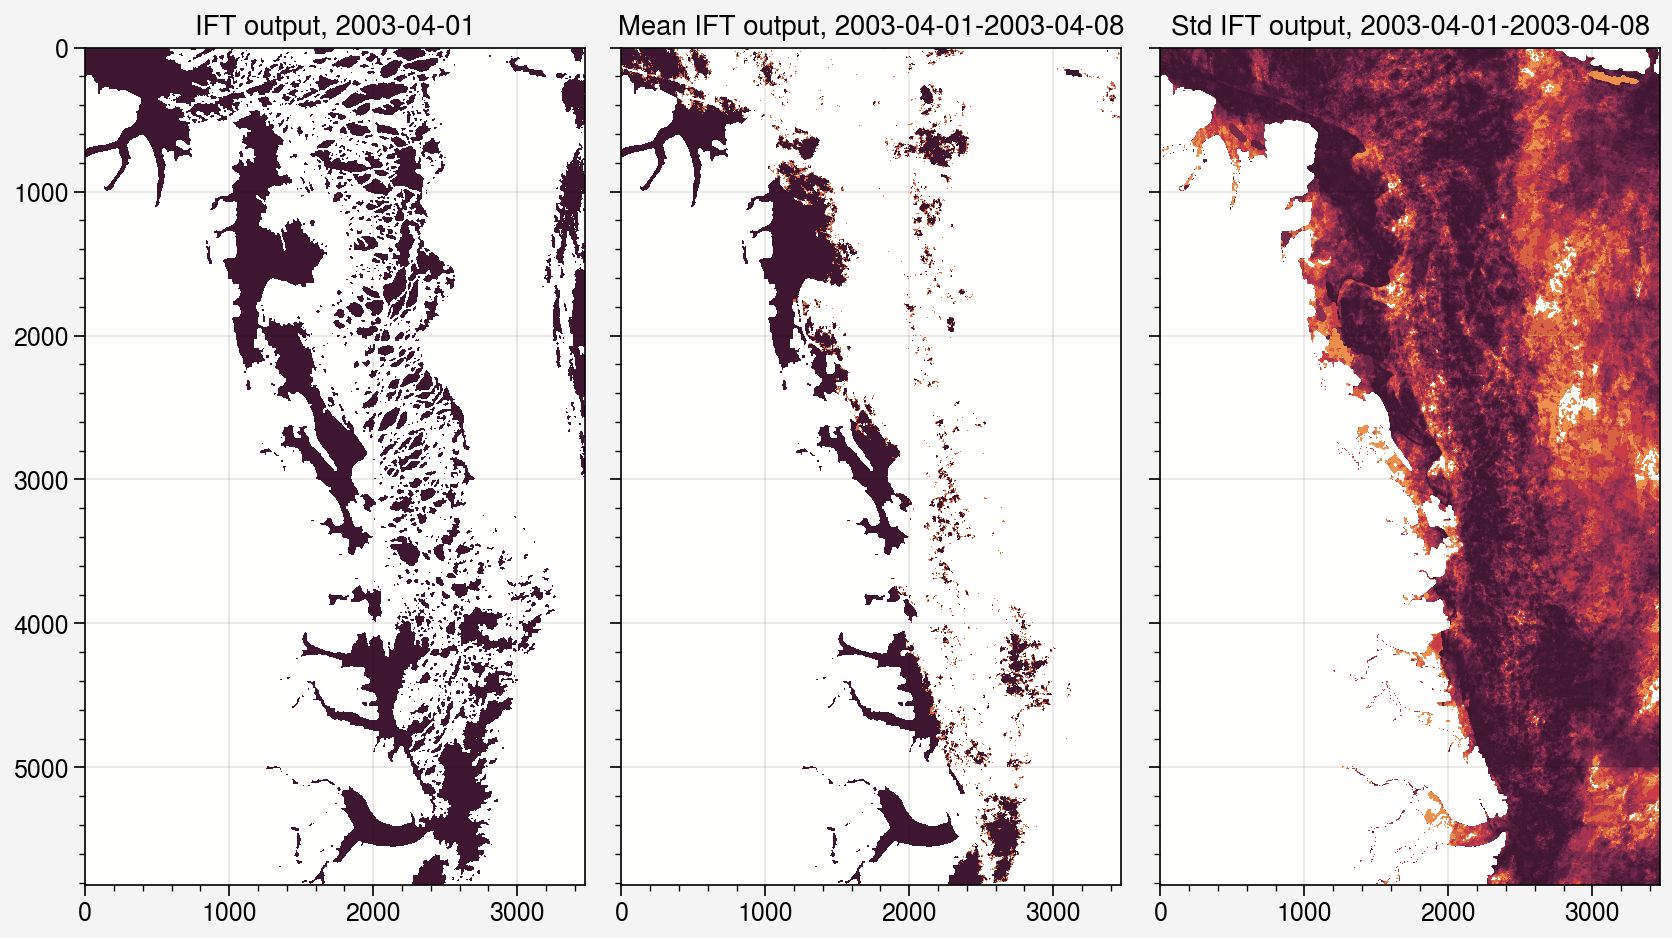

In [60]:
# 2 weeks
init = 0
last = 28
date1 = pd.to_datetime(fs_pipeline_results[0].split('.')[0]).strftime('%Y-%m-%d')
date_n = pd.to_datetime(fs_pipeline_results[14].split('.')[0]).strftime('%Y-%m-%d')

fig, ax = uplt.subplots(ncols=3)
ax[0].imshow(binary_imgs[init])
ax[1].imshow(np.median(masked_ice_images[init:last, :, :], axis=0))
ax[2].imshow(np.std(masked_ice_images[init:last, :, :], axis=0))
ax[0].format(title="IFT output, " + date1)
ax[1].format(title="Median IFT output, " + date1 + '-' + date_n)
ax[2].format(title="Std IFT output, "  + date1 + '-' + date_n)